# Do Our Dogs Reflect Us? A Portrait of Zurich's Dog Owners

## Exploratory Data Analysis: Dogs of Zurich

### EDA Step 0: Data Preparation

In [2]:
# Import pandas, matplotlib.pyplot, and seaborn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [3]:
cd C:\Users\Abhi\Desktop\DSC_Bootcamp_Sep2025

C:\Users\Abhi\Desktop\DSC_Bootcamp_Sep2025


In [4]:
# Read in the data to a variable called df 
df = pd.read_csv('./data/20151001hundehalter.csv')

In [5]:
# Understand the shape, dimensions, and data types 
n_rows = df.shape[0]
n_cols = df.shape[1]
print('dimensions:',df.shape)
print('columns & types:')
print(df.dtypes)

dimensions: (6980, 13)
columns & types:
HALTER_ID             int64
ALTER                object
GESCHLECHT           object
STADTKREIS          float64
STADTQUARTIER       float64
RASSE1               object
RASSE1_MISCHLING     object
RASSE2               object
RASSE2_MISCHLING    float64
RASSENTYP            object
GEBURTSJAHR_HUND      int64
GESCHLECHT_HUND      object
HUNDEFARBE           object
dtype: object


In [6]:
# Read the first 5 rows
df.head()

,HALTER_ID,ALTER,GESCHLECHT,STADTKREIS,STADTQUARTIER,RASSE1,RASSE1_MISCHLING,RASSE2,RASSE2_MISCHLING,RASSENTYP,GEBURTSJAHR_HUND,GESCHLECHT_HUND,HUNDEFARBE
0,126,51-60,m,9.0,92.0,Welsh Terrier,NaN,NaN,NaN,K,2011,w,schwarz/braun
1,574,61-70,w,2.0,23.0,Cairn Terrier,NaN,NaN,NaN,K,2002,w,brindle
2,695,41-50,m,6.0,63.0,Labrador Retriever,NaN,NaN,NaN,I,2012,w,braun
3,893,61-70,w,7.0,71.0,Mittelschnauzer,NaN,NaN,NaN,I,2010,w,schwarz
4,1177,51-60,m,10.0,102.0,Shih Tzu,NaN,NaN,NaN,K,2011,m,schwarz/weiss


In [7]:
# Columns with missing values
cols_with_missing = {}
for col in df.columns:
    missing_cols = n_rows - df[col].count()
    if missing_cols:
        cols_with_missing[col] = missing_cols
        print(col, cols_with_missing[col])

ALTER 2
STADTKREIS 2
STADTQUARTIER 2
RASSE1_MISCHLING 6312
RASSE2 6443
RASSE2_MISCHLING 6980
RASSENTYP 174


In [8]:
# Remove columns with more than 100 missing values 
cols_to_remove = []
rows_to_remove = []
for col in cols_with_missing:
    if cols_with_missing[col] > 100:
        cols_to_remove.append(col)
    else:
        rows_to_remove.append(col)

print('columns to remove:', cols_to_remove)
df.drop(columns=cols_to_remove, axis=1, inplace=True)
print('cols removed:',n_cols - df.shape[1])

print('rows to remove:', rows_to_remove)
df.dropna(subset = rows_to_remove, inplace=True)
first_rows_removed = n_rows - df.shape[0]
print('rows removed:',first_rows_removed)

columns to remove: ['RASSE1_MISCHLING', 'RASSE2', 'RASSE2_MISCHLING', 'RASSENTYP']
cols removed: 4
rows to remove: ['ALTER', 'STADTKREIS', 'STADTQUARTIER']
rows removed: 3


In [9]:
# Rename column headings to English for better understanding 
df.rename(columns={
  'HALTER_ID':'holder_id',
  'ALTER':'age',
  'GESCHLECHT':'gender',
  'STADTKREIS':'district',
  'STADTQUARTIER':'neighborhood',
  'RASSE1':'breed',
  'RASSENTYP':'breed_type',
  'GEBURTSJAHR_HUND':'dog_birth_year',
  'GESCHLECHT_HUND': 'dog_gender',
  'HUNDEFARBE':'dog_color',
}, inplace=True)

In [18]:
# Check for any missing values in the different columns
df.isna().sum()

holder_id         0
age               0
gender            0
district          0
neighborhood      0
breed             0
dog_birth_year    0
dog_gender        0
dog_color         0
dtype: int64

In [20]:
df.head()

,holder_id,age,gender,district,neighborhood,breed,dog_birth_year,dog_gender,dog_color
0,126,51-60,m,9.0,92.0,Welsh Terrier,2011,w,schwarz/braun
1,574,61-70,w,2.0,23.0,Cairn Terrier,2002,w,brindle
2,695,41-50,m,6.0,63.0,Labrador Retriever,2012,w,braun
3,893,61-70,w,7.0,71.0,Mittelschnauzer,2010,w,schwarz
4,1177,51-60,m,10.0,102.0,Shih Tzu,2011,m,schwarz/weiss


In [24]:
# Confirm Dataset dimensions
print("Dataset shape:", df.shape)

# Data types and non-null counts
df.info()

Dataset shape: (6977, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 6977 entries, 0 to 6979
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   holder_id       6977 non-null   int64  
 1   age             6977 non-null   object 
 2   gender          6977 non-null   object 
 3   district        6977 non-null   float64
 4   neighborhood    6977 non-null   float64
 5   breed           6977 non-null   object 
 6   dog_birth_year  6977 non-null   int64  
 7   dog_gender      6977 non-null   object 
 8   dog_color       6977 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 545.1+ KB


### EDA Step 1: Look at the number of dogs, owners, and how many dogs per owner

In [28]:
print("Number of dogs:", len(df))
print("Number of unique owners:", df['holder_id'].nunique())

Number of dogs: 6977
Number of unique owners: 6313


In [37]:
#Check how many dogs per owner
dogs_per_owner = df.groupby('holder_id').size()

dogs_per_owner.describe()

count    6313.000000
mean        1.105180
std         0.407503
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        13.000000
dtype: float64

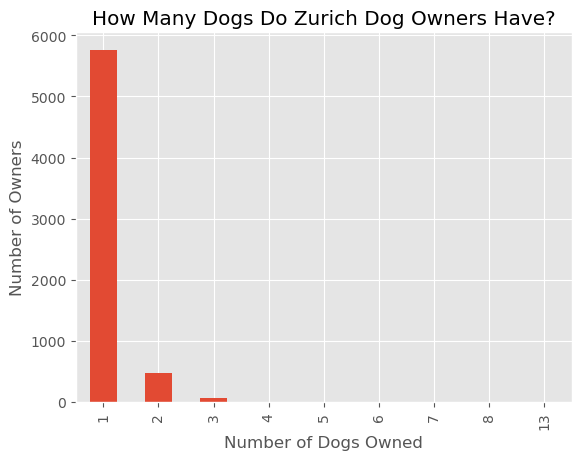

In [40]:
#Visalize the # of dogs per owner 
import matplotlib.pyplot as plt

dogs_per_owner.value_counts().sort_index().plot(kind='bar')

plt.xlabel('Number of Dogs Owned')
plt.ylabel('Number of Owners')
plt.title('How Many Dogs Do Zurich Dog Owners Have?')
plt.show()

### EDA Step 2: Explore who the owners are

In [43]:
# Start with gender counts
df['gender'].value_counts()

gender
w    4782
m    2195
Name: count, dtype: int64

In [45]:
# Convert counts to percentages 
df['gender'].value_counts(normalize=True) * 100

gender
w    68.539487
m    31.460513
Name: proportion, dtype: float64

In [47]:
# Look at age of the owner and # of dogs they own
df['age'].value_counts().sort_index()

age
20-Nov      41
21-30      786
31-40     1266
41-50     1491
51-60     1512
61-70     1042
71-80      644
81-90      179
91-100      16
Name: count, dtype: int64

In [52]:
# Fix the type for the first category
df['age'] = df['age'].replace('20-Nov', '11-20')

In [211]:
# Create a variable called owners_by_age
owners_by_age =  df['age'].value_counts().sort_index()
print(owners_by_age)

age
11-20       41
21-30      786
31-40     1266
41-50     1487
51-60     1511
61-70     1042
71-80      643
81-90      179
91-100      16
Name: count, dtype: int64


In [68]:
# Look at the gender of the owners 
owners_by_gender =  df['gender'].value_counts()
print(owners_by_gender)

gender
w    4782
m    2195
Name: count, dtype: int64


In [70]:
# Group owners by age
female_owners_ages = np.array(df[df['gender'] == 'w']['age'].value_counts().sort_index())
male_owners_ages = np.array(df[df['gender'] == 'm']['age'].value_counts().sort_index())

print(female_owners_ages)

[  31  605  864  989 1039  697  426  119   12]


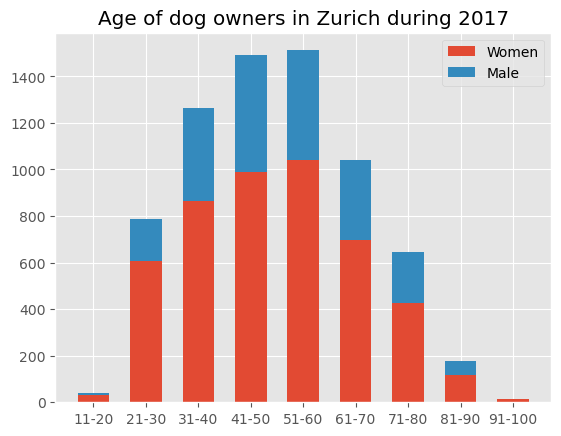

In [72]:
fig, ax = plt.subplots()
bottom = np.zeros(len(owners_by_age.index))

age_by_gender = {
  'Women': female_owners_ages,
  'Men': male_owners_ages
}

# Add woman
women = ax.bar(owners_by_age.index, female_owners_ages, 0.6, label='Women', bottom=bottom)
bottom += female_owners_ages

male = ax.bar(owners_by_age.index, male_owners_ages, 0.6, label='Male', bottom=bottom)
bottom += male_owners_ages

ax.set_title('Age of dog owners in Zurich during 2017')
ax.legend()

plt.show()

### EDA Step 3: Meet the dogs!

In [74]:
# Look at how the dogs are registered 
df['district'].value_counts().sort_index()

district
1.0      118
2.0      602
3.0      653
4.0      372
5.0      196
6.0      473
7.0      999
8.0      370
9.0      845
10.0     691
11.0    1169
12.0     489
Name: count, dtype: int64

In [77]:
# Look at the top 15 breeds 
df['breed'].value_counts().head(15)

breed
Mischling klein                652
Chihuahua                      495
Labrador Retriever             446
Jack Russel Terrier            298
Yorkshire Terrier              280
Malteser                       192
Mops                           178
Golden Retriever               174
Französische Bulldogge         170
Mischling gross                136
Pudel                          108
West Highland White Terrier    105
Border Collie                  101
Schäfer                         93
Pekingese                       87
Name: count, dtype: int64

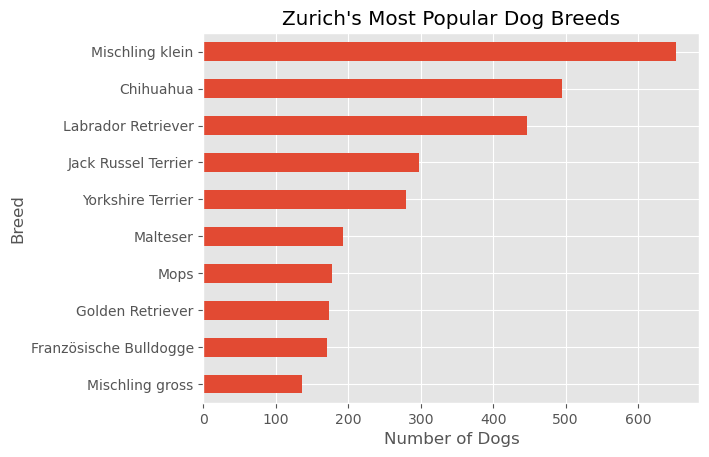

In [81]:
# Visualize the top 10 popular breeds
top_breeds = df['breed'].value_counts().head(10)

top_breeds.sort_values().plot(kind='barh')

plt.xlabel('Number of Dogs')
plt.ylabel('Breed')
plt.title("Zurich's Most Popular Dog Breeds")
plt.show()

In [84]:
# Look at the dog gender 
df['dog_gender'].value_counts()

dog_gender
w    3548
m    3429
Name: count, dtype: int64

In [98]:
# Look at age of the dog 
df['dog_birth_year'].value_counts()

dog_birth_year
2012    624
2013    588
2010    568
2009    560
2011    559
2014    554
2008    506
2007    490
2006    462
2005    443
2004    425
2003    329
2002    277
2015    192
2001    172
2000    118
1999     59
1998     32
1997     10
1995      1
1980      1
8         1
1         1
1994      1
1962      1
5012      1
2016      1
1996      1
Name: count, dtype: int64

In [100]:
# Clean the invalid years
invalid_years = [1, 8, 1962, 1980, 5012, 2016]

df = df[~df['dog_birth_year'].isin(invalid_years)].copy()

In [104]:
# Confirm that age looks fine
df['dog_birth_year'].value_counts().sort_index()

dog_birth_year
1994      1
1995      1
1996      1
1997     10
1998     32
1999     59
2000    118
2001    172
2002    277
2003    329
2004    425
2005    443
2006    462
2007    490
2008    506
2009    560
2010    568
2011    559
2012    624
2013    588
2014    554
2015    192
Name: count, dtype: int64

In [106]:
# Calculate Age of the dog 
df['dog_age'] = 2015 - df['dog_birth_year']

df['dog_age'].describe()

count    6971.000000
mean        6.630039
std         4.113610
min         0.000000
25%         3.000000
50%         6.000000
75%        10.000000
max        21.000000
Name: dog_age, dtype: float64

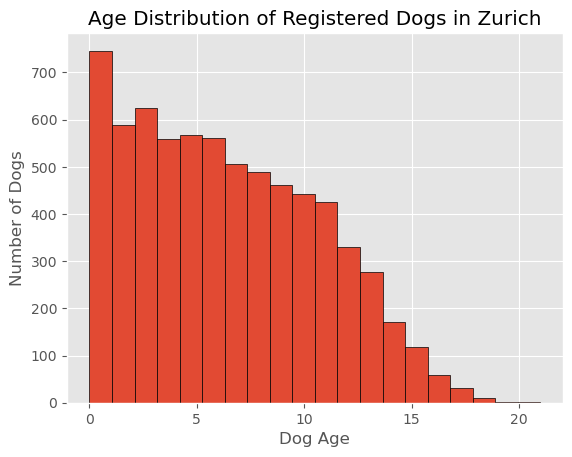

In [108]:
df['dog_age'].plot(
    kind='hist',
    bins=20,
    edgecolor='black'
)

plt.xlabel('Dog Age')
plt.ylabel('Number of Dogs')
plt.title('Age Distribution of Registered Dogs in Zurich')
plt.show()

##### Observations across Step 1-3:
1. Majority of dog owners only own one dog. 
2. Dog ownership in this dataset is concentrated among ages 31–70, especially 41–60.
3. Female (w) owners substantially outnumber male (m) owners: about 69% vs. 31%.
4. Dog gender is almost perfectly balanced.
5. Small mixed-breed dogs (Mischling) are the most common breed category, followed by Chihuahua and Labrador Retriever.
6. The typical dog is around 6 years old, with most between roughly 3 and 10.
7. Age of dogs ranging from puppies to a plausible maximum age of 21.

### EDA Step 4: Investigate relationships 

#### Question 1: Do men and women choose different dogs?

In [130]:
# Top breeds owned by gender of the owner
breed_gender = pd.crosstab(
    df['breed'],
    df['gender']
)

breed_gender.head()

gender,m,w
breed,,
Affenpinscher,1,0
Afghane,2,4
Afghanischer Windhund,0,2
Airedale Terrier,5,13
Akita Inu,1,5


In [213]:
# Calculate percentages 
breed_by_gender = pd.crosstab(
    df['breed'],
    df['gender'],
    normalize='columns'
) * 100

print(breed_by_gender)

gender                        m         w
breed                                    
Affenpinscher          0.045600  0.000000
Afghane                0.091199  0.083717
Afghanischer Windhund  0.000000  0.041859
Airedale Terrier       0.227998  0.272080
Akita Inu              0.045600  0.104646
...                         ...       ...
Zwergpinscher          0.866393  0.753453
Zwergpudel             0.820793  1.130180
Zwergrauhaardackel     0.045600  0.188363
Zwergschnauzer         0.455996  0.439514
Zwergspitz             0.638395  0.879029

[301 rows x 2 columns]


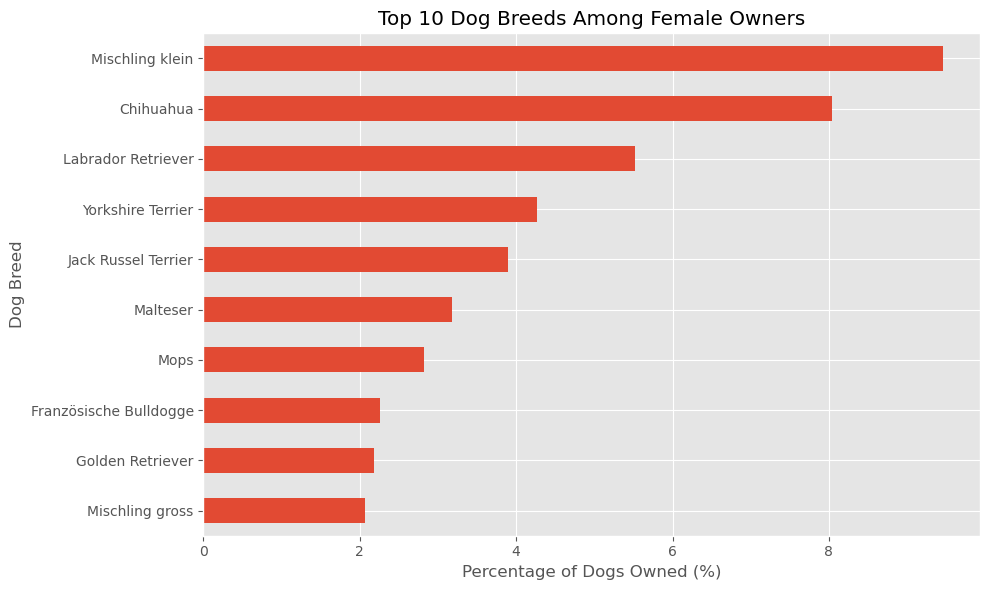

In [151]:
# Top 10 breeds among female owners
top_female = breed_by_gender['w'].nlargest(10).sort_values()

plt.figure(figsize=(10, 6))

top_female.plot(kind='barh')

plt.title('Top 10 Dog Breeds Among Female Owners')
plt.xlabel('Percentage of Dogs Owned (%)')
plt.ylabel('Dog Breed')

plt.tight_layout()
plt.show()

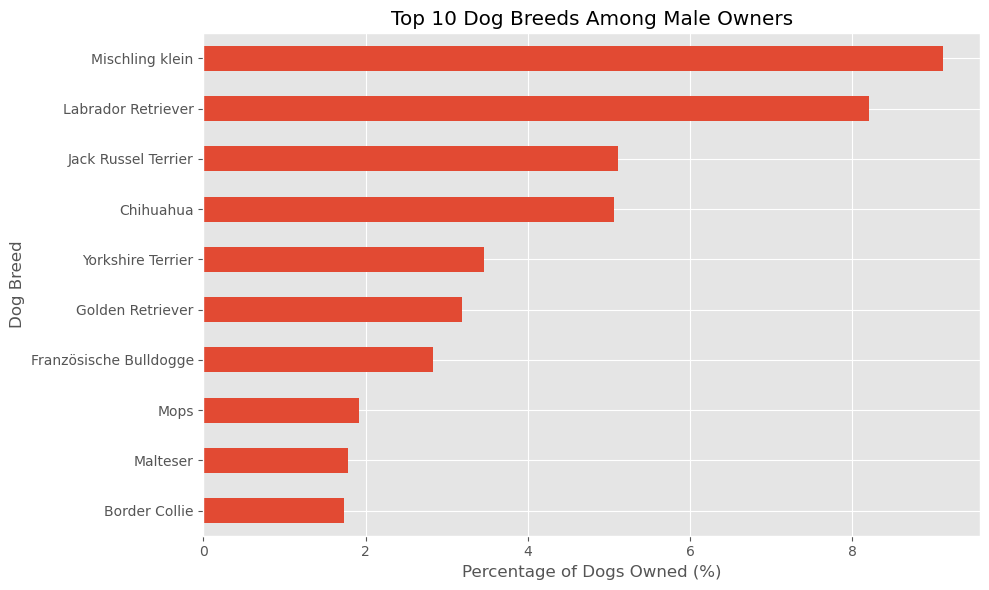

In [153]:
# Top 10 breeds among male owners
top_male = breed_by_gender['m'].nlargest(10).sort_values()

plt.figure(figsize=(10, 6))

top_male.plot(kind='barh')

plt.title('Top 10 Dog Breeds Among Male Owners')
plt.xlabel('Percentage of Dogs Owned (%)')
plt.ylabel('Dog Breed')

plt.tight_layout()
plt.show()

In [155]:
# Q. Which breeds different most between men and women? 
breed_by_gender['difference'] = (
    breed_by_gender['w'] - breed_by_gender['m']
)

In [157]:
# Looking at the positive difference (relatively more popular among women) 
breed_by_gender.sort_values(
    'difference',
    ascending=False
).head(10)

gender,m,w,difference
breed,,,
Chihuahua,5.061560,8.036835,2.975276
Malteser,1.778386,3.181247,1.402862
Pudel,0.638395,1.967350,1.328955
Bolonka Zwetna,0.319197,1.569694,1.250497
Mops,1.915185,2.825450,0.910265
Yorkshire Terrier,3.465572,4.269569,0.803997
Havaneser,0.319197,0.879029,0.559831
West Highland White Terrier,1.139991,1.674341,0.534350
Cairn Terrier,0.410397,0.920887,0.510491


In [159]:
# Looking at the negative difference (relatively more popular among men)
breed_by_gender.sort_values(
    'difference'
).head(10)

gender,m,w,difference
breed,,,
Labrador Retriever,8.207934,5.525324,-2.682610
Jack Russel Terrier,5.107159,3.892842,-1.214317
Golden Retriever,3.191974,2.176643,-1.015332
Deutscher Schäfer,1.732786,0.920887,-0.811899
Französische Bulldogge,2.827177,2.260360,-0.566817
Beagle,1.504788,1.025534,-0.479254
Border Collie,1.732786,1.318543,-0.414243
Shih Tzu,1.231190,0.837170,-0.394020
Entlebucher Sennenhund,0.455996,0.062788,-0.393209


##### Observations for Question 1: 
1. Mischling klein (small, mixed breed dogs) are a popular breed among women and men 
2. Chihuahua is more popular among women than men, followed by Malteser and Pudel.
3. Retrievers are more popular among men than women, as Labradors, Terriers, and Golden Retrievers are the top three choices for men. 

#### Question 2: Does dog preference change with owner age? 

In [217]:
# Cross tabulation between owner's age and breed 
age_breed = pd.crosstab(
    df['age'],
    df['breed']
)

age_breed

breed,Affenpinscher,Afghane,Afghanischer Windhund,Airedale Terrier,Akita Inu,Alano,Alaskan Malamute,Alpenländische Dachsbracke,Altdeutscher Hütehund,Altdeutscher Schäfer,...,Wolfspitz,Wäller,Yorkshire Terrier,Zwergdachshund,Zwergdackel,Zwergpinscher,Zwergpudel,Zwergrauhaardackel,Zwergschnauzer,Zwergspitz
age,,,,,,,,,,,,,,,,,,,,,
11-20,0,0,0,0,0,0,0,0,0,0,...,0,0,4,0,0,2,1,0,0,1
21-30,0,0,0,0,0,1,1,0,0,1,...,0,0,27,1,0,8,3,1,4,19
31-40,0,0,0,0,2,0,1,0,0,1,...,0,1,46,0,3,16,4,1,8,14
41-50,1,0,1,3,1,0,2,0,1,1,...,0,0,65,1,2,18,17,0,9,12
51-60,0,3,1,8,1,0,0,0,0,3,...,0,0,62,1,1,8,17,4,3,10
61-70,0,2,0,5,1,0,0,0,0,0,...,1,0,40,0,3,3,10,1,3,0
71-80,0,1,0,1,1,0,0,0,0,0,...,0,0,26,1,0,0,17,1,3,0
81-90,0,0,0,1,0,0,0,1,0,0,...,0,0,8,0,3,0,3,2,1,0
91-100,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,0,0


In [179]:
# Cross tabulation showing the top 3 breeds by each age-group category 
age_breed_pct = pd.crosstab(
    df['age'],
    df['breed'],
    normalize='index'
) * 100

# Convert to long format
age_breed_long = (
    age_breed_pct
    .stack()
    .reset_index(name='percentage')
)

# Get top 3 breeds within each age group
top3_by_age = (
    age_breed_long
    .sort_values(['age', 'percentage'], ascending=[True, False])
    .groupby('age', group_keys=False)
    .head(3)
)

top3_by_age

,age,breed,percentage
67,11-20,Chihuahua,24.390244
122,11-20,Französische Bulldogge,9.756098
293,11-20,Yorkshire Terrier,9.756098
368,21-30,Chihuahua,16.030534
423,21-30,Französische Bulldogge,6.997455
484,21-30,Mischling klein,6.743003
669,31-40,Chihuahua,8.925750
764,31-40,Labrador Retriever,7.424961
785,31-40,Mischling klein,7.424961
1086,41-50,Mischling klein,8.406187


##### Observations for Question 2: 
1. Chihuahua is the most popular dog breed for 11-40 ages.
2. Mischling klein (small mixed-breed dogs) is the most popular dog breed among people aged 41 years and up. 

#### Question 3: Do Zurich districts have different dog preferences? 

In [141]:
# Count of dogs by different districts 
df['district'].value_counts().sort_index()

district
1.0      118
2.0      601
3.0      652
4.0      372
5.0      196
6.0      473
7.0      997
8.0      370
9.0      844
10.0     691
11.0    1168
12.0     489
Name: count, dtype: int64

In [185]:
# Percentage of each breed within each district
district_breed_pct = pd.crosstab(
    df['district'],
    df['breed'],
    normalize='index'
) * 100

# Convert to long format
district_breed_long = (
    district_breed_pct
    .stack()
    .reset_index(name='percentage')
)

# Find top 3 breeds in each district
top3_by_district = (
    district_breed_long
    .sort_values(
        ['district', 'percentage'],
        ascending=[True, False]
    )
    .groupby('district', group_keys=False)
    .head(3)
)

top3_by_district

,district,breed,percentage
183,1.0,Mischling klein,9.322034
67,1.0,Chihuahua,8.474576
162,1.0,Labrador Retriever,4.237288
484,2.0,Mischling klein,8.818636
463,2.0,Labrador Retriever,8.153078
368,2.0,Chihuahua,6.156406
785,3.0,Mischling klein,10.582822
669,3.0,Chihuahua,9.509202
764,3.0,Labrador Retriever,5.981595
1086,4.0,Mischling klein,9.946237


##### Observations for Question 3: 

1. No discernable pattern of breeds between the districts. Overall, small mixed-breed dogs remain popular in almost all Zurich districts


#### Question 4: Do people choose dogs of the same gender as themselves? 

In [202]:
# Cross tabulation of owner gender and dog gender 
gender_counts = pd.crosstab(
    df['gender'],
    df['dog_gender']
)

gender_counts

dog_gender,m,w
gender,,
m,1178,1015
w,2248,2530


In [190]:
# Cross tabulation of owner gender and dog gender (in percentages) 
owner_dog_gender = pd.crosstab(
    df['gender'],
    df['dog_gender'],
    normalize='index'
) * 100

owner_dog_gender

dog_gender,m,w
gender,,
m,53.716370,46.283630
w,47.048974,52.951026


In [192]:
# Rename the labels 
owner_dog_gender = owner_dog_gender.rename(
    index={'m': 'Male Owner', 'w': 'Female Owner'},
    columns={'m': 'Male Dog', 'w': 'Female Dog'}
)

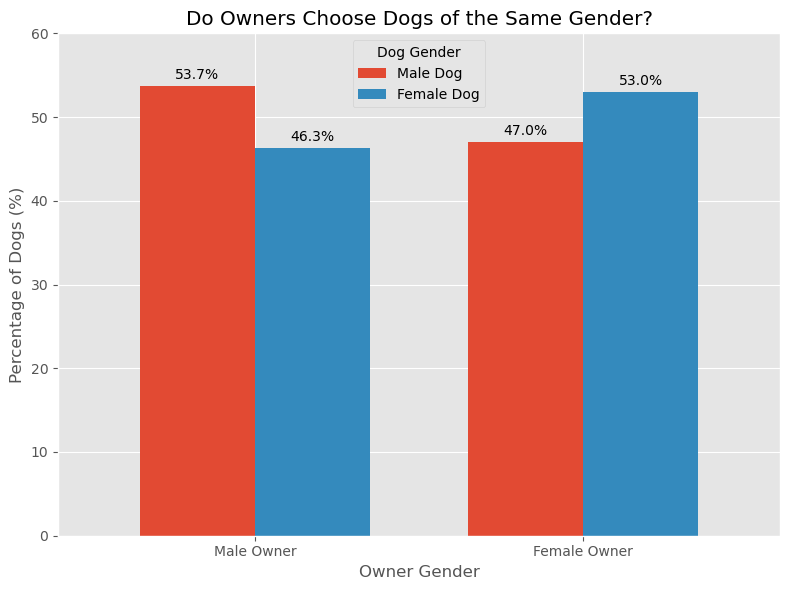

In [196]:
# Visualize the cross-tab 
ax = owner_dog_gender.plot(
    kind='bar',
    figsize=(8, 6),
    width=0.7
)

plt.title("Do Owners Choose Dogs of the Same Gender?")
plt.xlabel('Owner Gender')
plt.ylabel('Percentage of Dogs (%)')
plt.xticks(rotation=0)

plt.legend(title='Dog Gender')
plt.ylim(0, 60)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.tight_layout()
plt.show()

In [200]:
# Run a statistical test to assess whether the difference is statistically significant 
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(gender_counts)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")

Chi-square statistic: 26.47
P-value: 0.0000


##### Observations for Question 4: 
1. There appears to be a modest relationship between an owner’s gender and the gender of their dog. Male owners were more likely to own male dogs (53.7%), while female owners were more likely to own female dogs (53.0%). A chi-square test confirmed that this association was statistically significant (χ² = 26.47, p < 0.001). While the differences are relatively small, the results suggest that Zurich dog owners show a slight preference for dogs of the same gender as themselves.